# Banking Fraud Detection — Temporal Validation

A time-aware train-test split is created to prevent future information from influencing model training and evaluation.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#The original transaction dataset is loaded for temporal validation.

df = pd.read_csv("../data/financial_fraud_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10000, 10)


In [27]:
#The transaction timestamp is converted into datetime format so that transactions can be ordered chronologically.

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Timestamp converted successfully.")
print("Data type:", df["timestamp"].dtype)

Timestamp converted successfully.
Data type: datetime64[ns]


In [28]:
# Transactions are sorted according to their timestamp so that earlier transactions precede later transactions.
df = df.sort_values("timestamp").reset_index(drop=True)

print("Transactions sorted chronologically.")
print("Earliest transaction:", df["timestamp"].min())
print("Latest transaction:", df["timestamp"].max())


Transactions sorted chronologically.
Earliest transaction: 2022-01-01 02:45:55
Latest transaction: 2024-12-30 18:50:24


In [29]:
print("First 5 transactions:")
display(df[["timestamp", "is_fraud"]].head())

print("\nLast 5 transactions:")
display(df[["timestamp", "is_fraud"]].tail())

First 5 transactions:


,timestamp,is_fraud
0,2022-01-01 02:45:55,0
1,2022-01-01 10:19:15,0
2,2022-01-01 13:45:01,0
3,2022-01-01 14:11:54,0
4,2022-01-01 17:17:58,0



Last 5 transactions:


,timestamp,is_fraud
9995,2024-12-29 20:17:53,0
9996,2024-12-30 01:32:32,0
9997,2024-12-30 07:02:02,0
9998,2024-12-30 08:16:32,0
9999,2024-12-30 18:50:24,0


In [30]:
# The dataset is divided chronologically, with the earliest 80% of transactions used for training and the latest 20% reserved for testing.

split_index = int(len(df) * 0.80)

print("Total transactions:", len(df))
print("Training transactions:", split_index)
print("Testing transactions:", len(df) - split_index)

Total transactions: 10000
Training transactions: 8000
Testing transactions: 2000


In [31]:
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()


print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (8000, 10)
Testing shape: (2000, 10)


In [32]:
# The temporal boundaries of the training and testing sets are checked to confirm that the test period occurs after the training period.

print("Training period:")
print(train_df["timestamp"].min(), "to", train_df["timestamp"].max())

print("\nTesting period:")
print(test_df["timestamp"].min(), "to", test_df["timestamp"].max())

print("\nTemporal separation valid:",
      train_df["timestamp"].max() < test_df["timestamp"].min())

Training period:
2022-01-01 02:45:55 to 2024-05-23 11:14:52

Testing period:
2024-05-23 11:21:44 to 2024-12-30 18:50:24

Temporal separation valid: True


In [33]:
# The fraud distribution in the training and testing periods is examined to ensure that both sets contain fraudulent and legitimate transactions.
print("Training class distribution:")
print(train_df["is_fraud"].value_counts())
print("\nTraining class percentages:")
print((train_df["is_fraud"].value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution:")
print(test_df["is_fraud"].value_counts())
print("\nTesting class percentages:")
print((test_df["is_fraud"].value_counts(normalize=True) * 100).round(2))

Training class distribution:
is_fraud
0    7856
1     144
Name: count, dtype: int64

Training class percentages:
is_fraud
0    98.2
1     1.8
Name: proportion, dtype: float64

Testing class distribution:
is_fraud
0    1956
1      44
Name: count, dtype: int64

Testing class percentages:
is_fraud
0    97.8
1     2.2
Name: proportion, dtype: float64


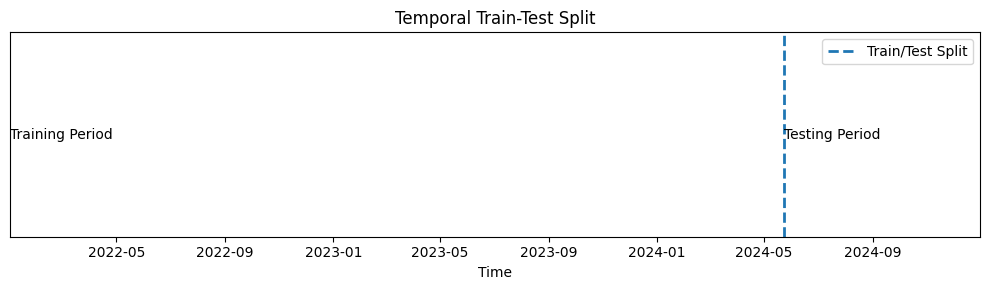

In [34]:
plt.figure(figsize=(10, 3))

split_time = test_df["timestamp"].min()

plt.axvline(
    split_time,
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)
plt.xlim(
    df["timestamp"].min(),
    df["timestamp"].max()
)

plt.text(
    train_df["timestamp"].min(),
    0.5,
    "Training Period",
    ha="left",
    va="center"
)

plt.text(
    test_df["timestamp"].min(),
    0.5,
    "Testing Period",
    ha="left",
    va="center"
)

plt.ylim(0, 1)
plt.yticks([])
plt.xlabel("Time")
plt.title("Temporal Train-Test Split")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
#The temporally separated training and testing datasets are saved so that the same fixed split can be consistently reused in subsequent modeling experiments.
train_df.to_csv("../data/train_temporal.csv", index=False)
test_df.to_csv("../data/test_temporal.csv", index=False)

print("Temporal train-test splits saved successfully.")
print("Training file: ../data/train_temporal.csv")
print("Testing file: ../data/test_temporal.csv")

Temporal train-test splits saved successfully.
Training file: ../data/train_temporal.csv
Testing file: ../data/test_temporal.csv


### Leakage Prevention

The test set contains transactions from a later time period than the training set. Therefore, information from future transactions is not used during model training or preprocessing.

All transformations required for modeling will be fitted using the training data and then applied to the test data.

### Temporal Validation Summary

- The dataset was sorted chronologically using the transaction timestamp.
- The earliest 80% of transactions were assigned to the training set.
- The latest 20% of transactions were reserved for testing.
- The training and testing periods are temporally separated.
- Class distributions were examined after the temporal split.
- The temporal train-test datasets were saved for consistent reuse in subsequent experiments.
- Future test information is kept separate from model development.
- This temporal split will be used consistently in the subsequent modeling experiments.